## Deconvolution using PCA

### Step 0: Load reference data (scRNA-seq)

In [18]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [19]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [20]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

### Step 1: Prep data for Geneformer

In [21]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:50: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cell_id"] = adata.obs.index


### Step 2: Create pseudobulk

In [22]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type", # cell type column
                                             n_pseudobulks = 500, # Number of pseudobulk samples to be created
                                             target_proportion_min = 0.1, # expected min cell type proportion
                                             target_proportion_max = 0.80, # expected max cell type proportion
                                             n_cells_per_pseudobulk = 300, # number of cells to be used for pseudobulking per sample
                                             random_state = 42 # random state for reproducibility
                                            )

### Step 3: Create signature matrix

In [23]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata,
                                  sample_col = "batch", # sample id column
                                  cell_type_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:239: UserWarning: Expression matrix contains non-integer values. Raw counts are expected. 
  warnings.warn(
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:251: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


### Step 4: Extract Geneformer Embeddings

In [24]:
from embeddings import *

In [25]:
# Extract embeddings 
bulk_sig_mat_pc = extract_components(bulk_df = pseudo_bulk,
                                     sig_mat = sig_mat,
                                     mode = "pca",
                                     transform = True)

bulk_pc = bulk_sig_mat_pc["pca_bulk"]
sig_mat_pc = bulk_sig_mat_pc["sig_pca"]

Variance explained by 4 PCs: 100.00%


### Step 5: Run Non-Negative Least Squares (NNLS)

In [26]:
from deconvolution import *

In [27]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T, #columns should be embedding dimensions
                            signature_df = sig_mat_pc.T, #columns should be embedding dimensions
                            normalize = True)

Using 4 common features.
Running deconvolution...


In [28]:
#cell_prop_pred.to_csv("../outputs/PCA_estimated_proportions.csv")

### Step 6: Evaluate estimated proportions

In [29]:
from evaluation import *

In [30]:
cell_prop.head()

,NK cells,T cells,Monocytes,B cells
T cells_PB1,0.216667,0.363333,0.236667,0.183333
B cells_PB2,0.053333,0.090000,0.090000,0.766667
T cells_PB3,0.123333,0.613333,0.130000,0.133333
Monocytes_PB4,0.156667,0.146667,0.520000,0.176667
T cells_PB5,0.276667,0.210000,0.233333,0.280000


In [31]:
#Compute RMSE per cell type
rmse_per_cell_type = compute_rmse(true_df = cell_prop, # sample (rows) x cell type (columns)
                                 pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
                                 return_per_celltype = True)

rmse_per_cell_type = pd.DataFrame(rmse_per_cell_type)

rmse_per_cell_type

,overall,per_celltype
NK cells,0.178033,0.099594
T cells,0.178033,0.233331
Monocytes,0.178033,0.217857
B cells,0.178033,0.122309


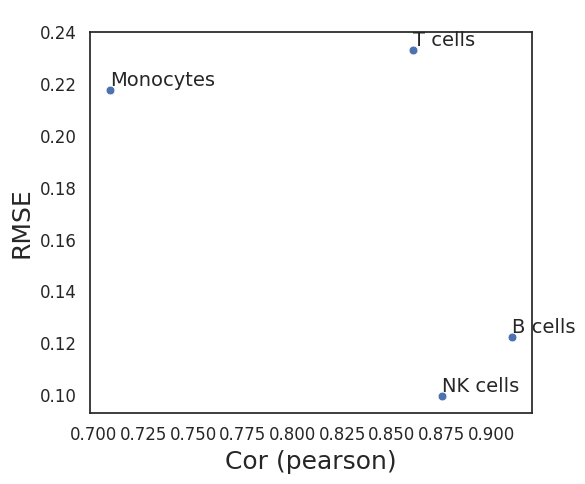

In [32]:
# Visualize RMSE - Correlation plot
# Both RMSE and Correlation coefficients are overall values (i.e not stratified by cell type)
sns.set_style("white")
plot_rmse_vs_corr_by_celltype(
    true_df = cell_prop,
    pred_df = cell_prop_pred
)

In [33]:
from visualization import *

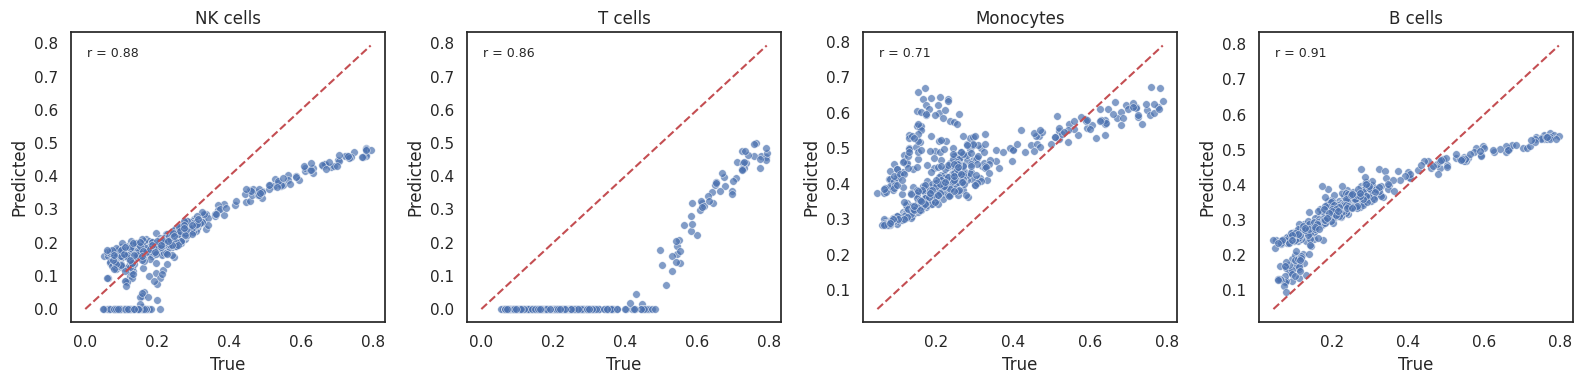

In [34]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
    
)

### Optional Step: Run Other Solvers

Using 4 common features.
Running deconvolution...


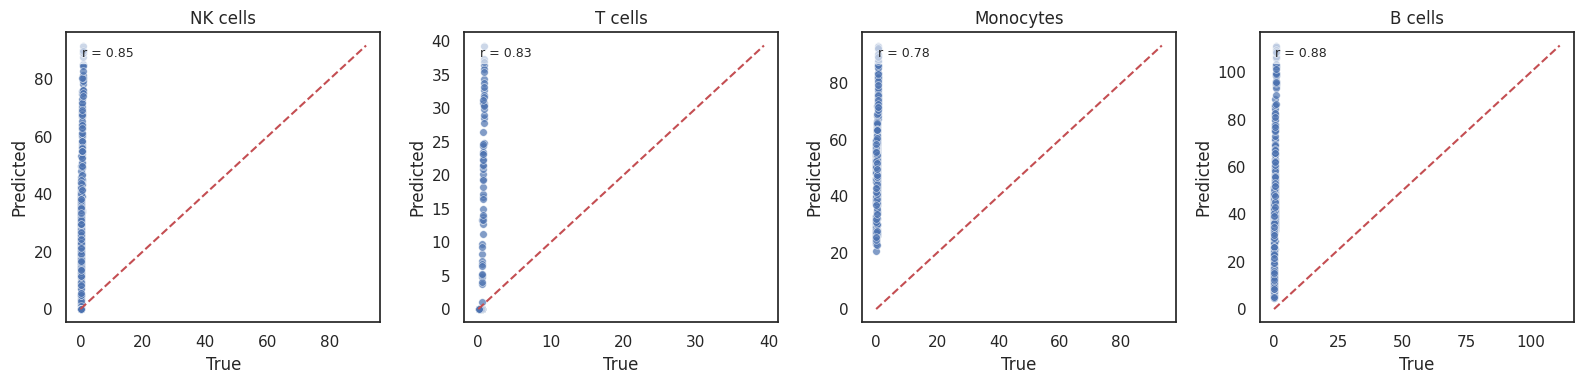

In [35]:
# Run ElasticNet
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T,
                                 signature_df = sig_mat_pc.T, 
                            solver= "elasticnet",
                                 normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)

Using 4 common features.
Running deconvolution...


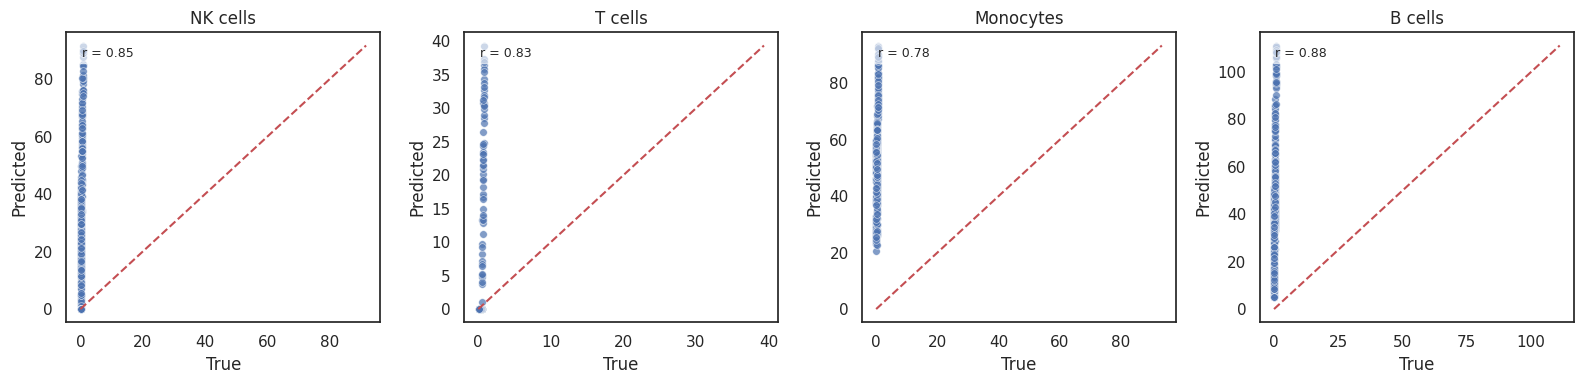

In [36]:
# Run ridge
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T,
                            signature_df = sig_mat_pc.T, 
                            solver= "ridge",
                            normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)

### Optional Step: Deconvolution using raw counts 

In [49]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk.T, #columns should be embedding dimensions
                            signature_df = sig_mat.T, #columns should be embedding dimensions
                            normalize = True)

Using 22982 common features.
Running deconvolution...


In [50]:
#Compute RMSE per cell type
rmse_per_cell_type = compute_rmse(true_df = cell_prop, # sample (rows) x cell type (columns)
                                 pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
                                 return_per_celltype = True)

rmse_per_cell_type = pd.DataFrame(rmse_per_cell_type)

rmse_per_cell_type

,overall,per_celltype
NK cells,0.017269,0.021567
T cells,0.017269,0.020804
Monocytes,0.017269,0.009724
B cells,0.017269,0.014155


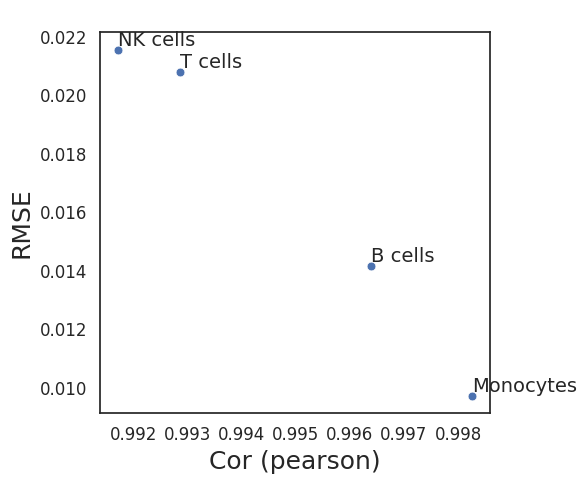

In [51]:
sns.set_style("white")
plot_rmse_vs_corr_by_celltype(
    true_df = cell_prop,
    pred_df = cell_prop_pred
)

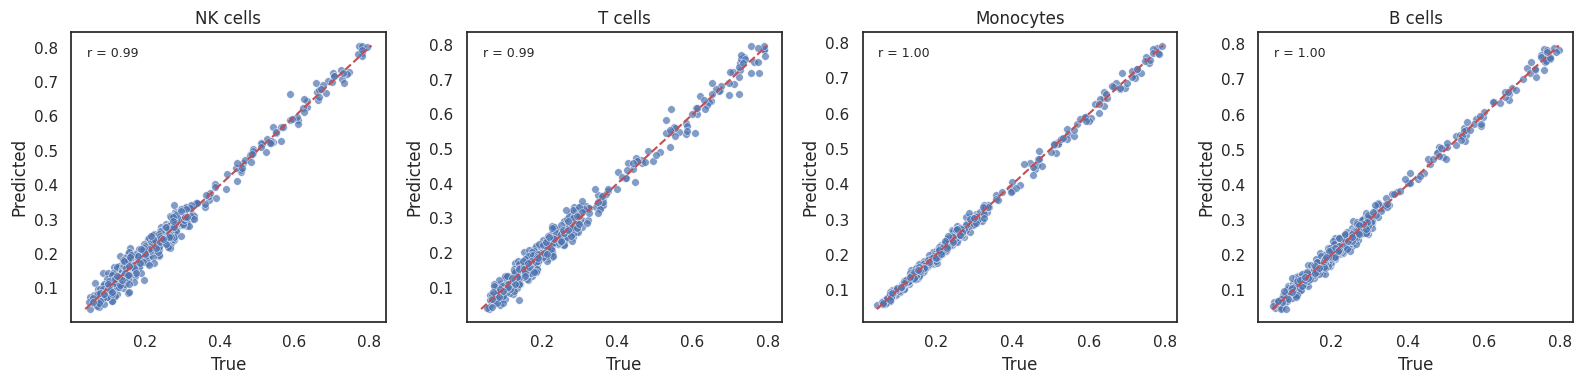

In [52]:
plot_true_vs_predicted(
    y_true_df = cell_prop, 
    y_pred_df = cell_prop_pred, 
    stratify_by_celltype= True,
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
    
)

In [53]:
#cell_prop_pred.to_csv("../results/Counts_estimated_proportions.csv")